# Import Libs

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier , plot_tree
from  sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report
from sklearn.preprocessing import OneHotEncoder , StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingClassifier

In [2]:
df = pd.read_csv("/kaggle/input/datasets/rakeshrau/social-network-ads/Social_Network_Ads.csv")
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [4]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [5]:
df.drop("User ID" , inplace = True , axis = 1)
df.head()

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0


In [6]:
df.isnull().sum()

Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

# Train Test Split

In [7]:
gender_map = { "Male" : 0 , "Female" : 1 }
df["Gender"] = df["Gender"].map(gender_map)
print(df.head())

X = df [["Gender" , "Age" , "EstimatedSalary"]] 
y =df [ "Purchased" ]

X_train , X_test , y_train , y_test = train_test_split( X , y , test_size = 0.2 , random_state=42 )

   Gender  Age  EstimatedSalary  Purchased
0       0   19            19000          0
1       0   35            20000          0
2       1   26            43000          0
3       1   27            57000          0
4       0   19            76000          0


# Encoding

In [8]:
scaler = StandardScaler()
scale_list = ["Age" , "EstimatedSalary"]
X_train_scaled = scaler.fit_transform(X_train[scale_list]) 
X_test_scaled  = scaler.transform(X_test[scale_list])



X_train_others = X_train[["Gender"]].values
X_test_others  = X_test[["Gender"]].values

X_train_final  =  np.hstack([X_train_scaled ,X_train_others ])
X_test_final =  np.hstack([X_test_scaled  , X_test_others])

# Modeling (DT & LR)

In [9]:
lr = LogisticRegression()
lr.fit(X_train_final , y_train)

y_pred_lr = lr.predict(X_test_final)

dt = DecisionTreeClassifier(     max_depth = 5 , 
                                 criterion= "entropy",  #sınıfların ne kadar karışık oldugunu olcer (regresyonda ne kadar uzak oldugu)
                                                        #entropy --> logaritmik işlem yapar Verideki karışıklığı azaltmaya odaklanır. 
                                                        #gini(default) --> daha hızlı(kare alma) yanlış sınıflandırmayı minimize etmeye çalışır
                                 min_samples_split = 3 , 
                                 min_samples_leaf=5 , 
                                 max_features = 1, 
                                 random_state = 42)
dt.fit(X_train_final , y_train)
y_pred_dt = dt.predict(X_test_final)

ensemble = VotingClassifier(
        estimators=[("LR" , lr ), ("DT" , dt )],
        voting = "soft"
)

ensemble.fit(X_train_final , y_train)
y_pred_ens = ensemble.predict(X_test_final)

# Visualization

MODEL: LR
Accuracy: 0.8875
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92        52
           1       0.91      0.75      0.82        28

    accuracy                           0.89        80
   macro avg       0.90      0.86      0.87        80
weighted avg       0.89      0.89      0.88        80



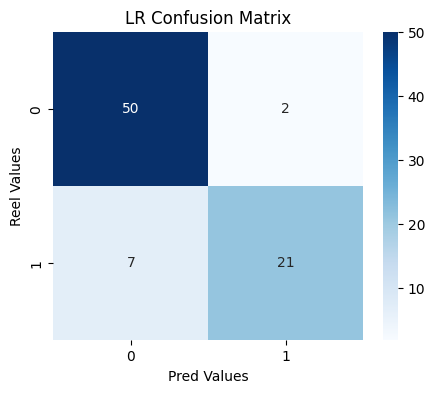

MODEL: DT
Accuracy: 0.9125
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.90      0.93        52
           1       0.84      0.93      0.88        28

    accuracy                           0.91        80
   macro avg       0.90      0.92      0.91        80
weighted avg       0.92      0.91      0.91        80



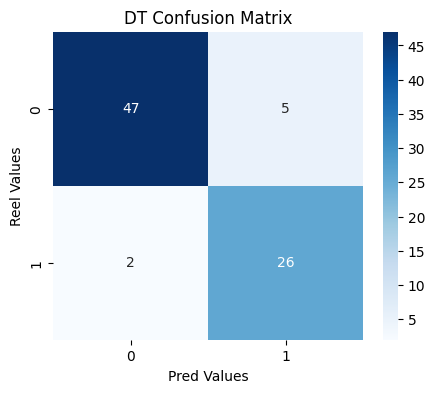

MODEL: ENS
Accuracy: 0.925
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.92      0.94        52
           1       0.87      0.93      0.90        28

    accuracy                           0.93        80
   macro avg       0.91      0.93      0.92        80
weighted avg       0.93      0.93      0.93        80



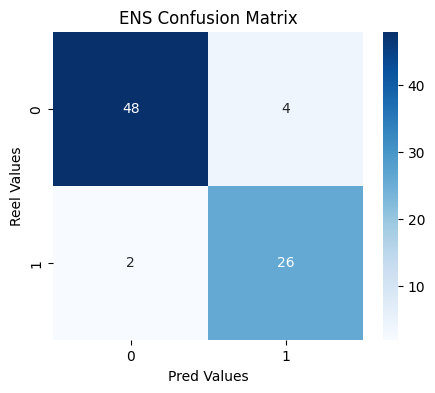

In [10]:
models = {
    "LR" : y_pred_lr ,
    "DT" : y_pred_dt ,
    "ENS":y_pred_ens
}

for name, y_pred in models.items():
    print(f"MODEL: {name}")
    
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc}")
    

    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.ylabel('Reel Values')
    plt.xlabel('Pred Values')
    plt.show()

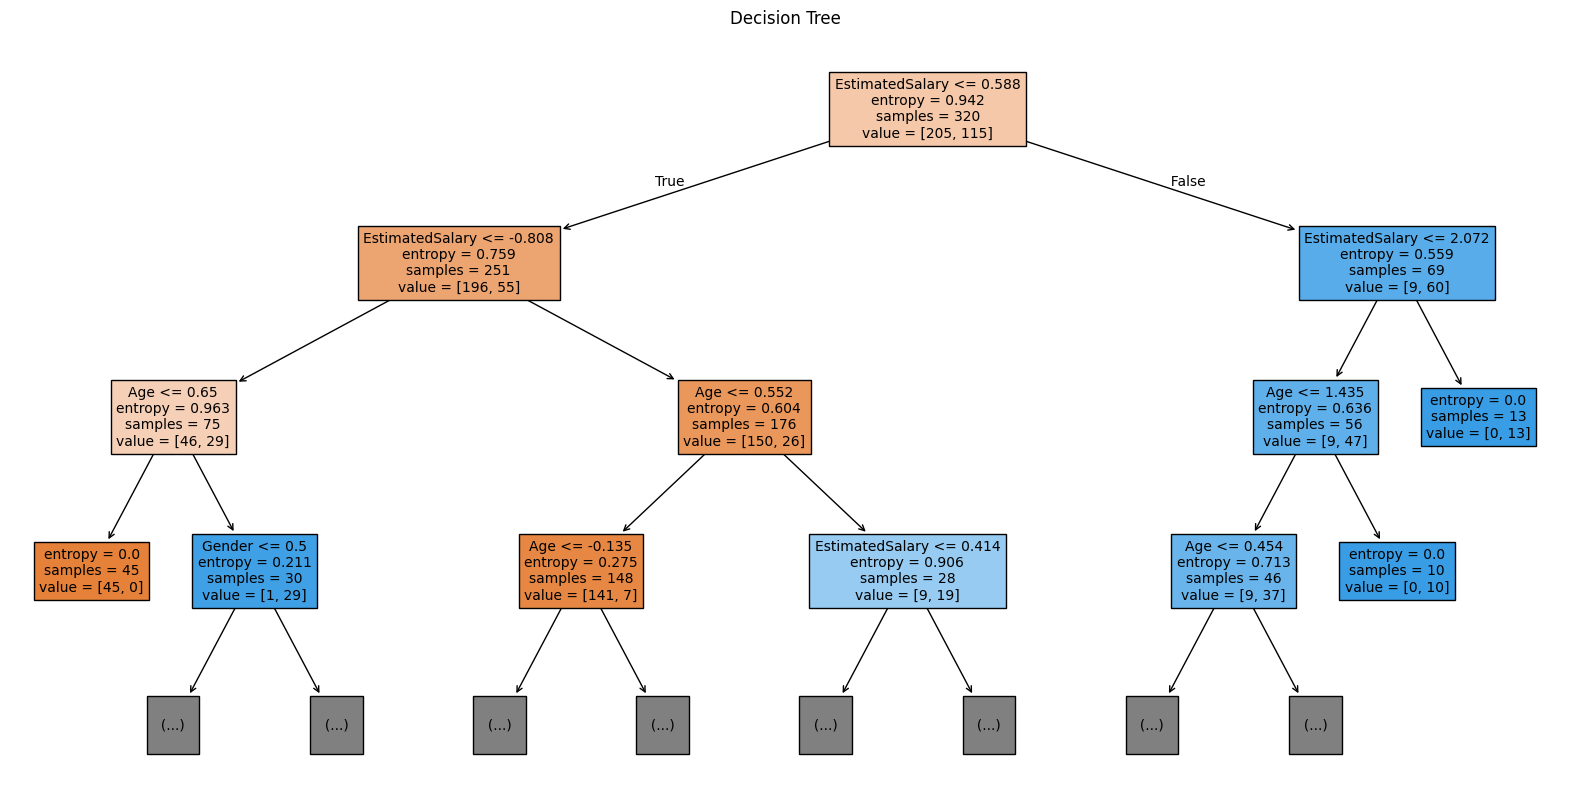

In [11]:
plt.figure(figsize=(20, 10))

plot_tree(dt, 
          feature_names= scale_list + ["Gender"],
          filled=True,     
          max_depth=3,     
          fontsize=10)

plt.title("Decision Tree")
plt.show()

<Axes: >

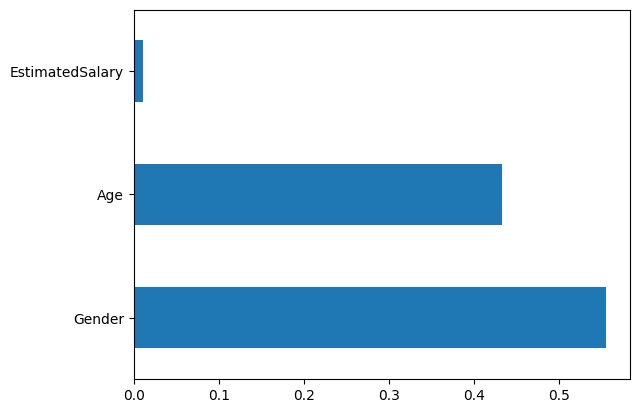

In [12]:
feat_importances = pd.Series(dt.feature_importances_, index=X.columns)
feat_importances.plot(kind='barh')